<a href="https://colab.research.google.com/github/Minerva-W/3511419_BD2_Assignment/blob/main/BD2_assignment_help.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import json
import zipfile
import os

try:
    with zipfile.ZipFile('JCPenneyFiles.zip', 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Files extracted successfully.")
except FileNotFoundError:
    print("Zip file not found. Ensure 'JCPenneyFiles.zip' is uploaded or files are present.")

Files extracted successfully.


In [ ]:
directory = 'JCPenneyFiles'
products_df = pd.read_csv(os.path.join(directory, 'products.csv'))
reviews_df = pd.read_csv(os.path.join(directory, 'reviews.csv'))
users_df = pd.read_csv(os.path.join(directory, 'users.csv'))
print(products_df)
print("-"*50)
print(users_df)
print("-"*50)
print(reviews_df)

                               Uniq_id           SKU  \
0     b6c0b6bea69c722939585baeac73c13d  pp5006380337   
1     93e5272c51d8cce02597e3ce67b7ad0a  pp5006380337   
2     013e320f2f2ec0cf5b3ff5418d688528  pp5006380337   
3     505e6633d81f2cb7400c0cfa0394c427  pp5006380337   
4     d969a8542122e1331e304b09f81a83f6  pp5006380337   
...                                ...           ...   
7977  16e3ca6b6a2d3f5da9a81df6cfe7e27a  pp5002691549   
7978  209bec04d9f194616358a77d7b41b314  pp5002691549   
7979  7a8a7cba7b69b4c46ceac1d9666d84f0  pp5002691549   
7980  9887bb20c12be3c09d094e97ac8d22be  pp5005921226   
7981  2cc49292b44cc12fe22206440d3e7472  pp5005921226   

                                             Name  \
0     Alfred Dunner® Essential Pull On Capri Pant   
1     Alfred Dunner® Essential Pull On Capri Pant   
2     Alfred Dunner® Essential Pull On Capri Pant   
3     Alfred Dunner® Essential Pull On Capri Pant   
4     Alfred Dunner® Essential Pull On Capri Pant   
...      

In [ ]:
# Merging reviews with products on Uniq_id
merged_df = pd.merge(reviews_df, products_df, on='Uniq_id', how='inner')

# Merging the result with users on Username
final_df = pd.merge(merged_df, users_df, on='Username', how='inner')

print(f"Combined Dataframe Shape: {final_df.shape}")
final_df.tail()

Combined Dataframe Shape: (39080, 11)


,Uniq_id,Username,Score,Review,SKU,Name,Description,Price,Av_Score,DOB,State
39075,2cc49292b44cc12fe22206440d3e7472,whxp1433,2,This bedspread is as practical as it is beauti...,pp5005921226,Hope Chest Embroidered Quilt & Accessories,NaN,NaN,3.0,27.07.1998,Alabama
39076,2cc49292b44cc12fe22206440d3e7472,kfqi4333,1,I purchased this same wedding ring quilt 16 ye...,pp5005921226,Hope Chest Embroidered Quilt & Accessories,NaN,NaN,3.0,06.08.1956,New York
39077,2cc49292b44cc12fe22206440d3e7472,bynj4221,0,This was a gift for my daughter and she loves ...,pp5005921226,Hope Chest Embroidered Quilt & Accessories,NaN,NaN,3.0,31.07.1983,Louisiana
39078,2cc49292b44cc12fe22206440d3e7472,eawq2222,1,I purchased these pillow shams as well as the ...,pp5005921226,Hope Chest Embroidered Quilt & Accessories,NaN,NaN,3.0,04.08.1964,Puerto Rico
39079,2cc49292b44cc12fe22206440d3e7472,mcxs2141,1,Needed a new quilt for my newly remodeled bedr...,pp5005921226,Hope Chest Embroidered Quilt & Accessories,NaN,NaN,3.0,08.08.1951,Kentucky


Text(0, 0.5, 'Count')

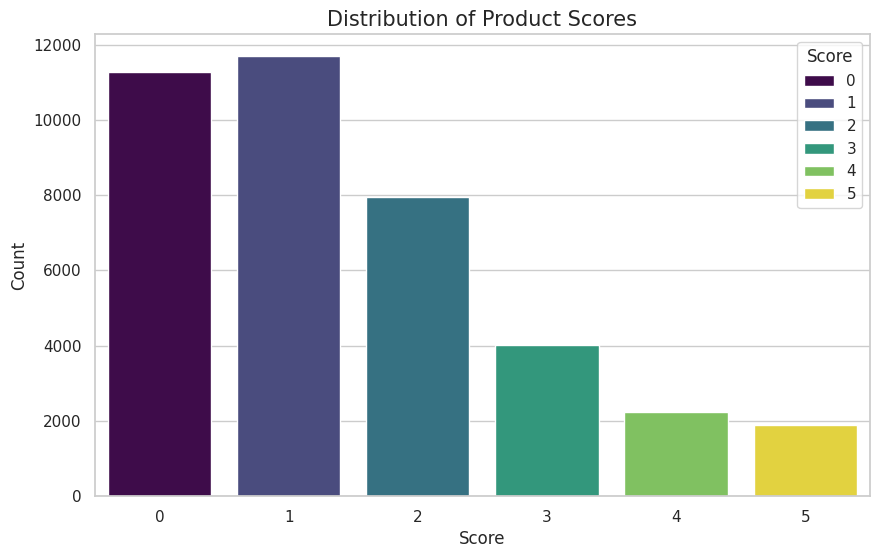

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the visual style
sns.set(style="whitegrid")

# Creating a bar chart of the 'Score' column
plt.figure(figsize=(10, 6))
sns.countplot(data=final_df, x='Score', hue='Score', palette='viridis', legend=True)

# Adding titles and labels
plt.title('Distribution of Product Scores', fontsize=15)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Count', fontsize=12)

In [ ]:
import pandas as pd
import json
import os

# Define the directory where files were extracted
data_dir = 'JCPenneyFiles'

# Load CSVs
products_df = pd.read_csv(os.path.join(data_dir, 'products.csv'))
reviews_df = pd.read_csv(os.path.join(data_dir, 'reviews.csv'))
users_df = pd.read_csv(os.path.join(data_dir, 'users.csv'))

# Load JSONs
# The previous attempt to load JSONs failed with 'JSONDecodeError: Extra data'.
# This error usually indicates that the JSON files are in JSON Lines (JSONL) format,
# where each line is a separate JSON object. We will modify the loading process
# to read each line and parse it as a JSON object.
products_json = []
with open(os.path.join(data_dir, 'jcpenney_products.json'), 'r') as f:
    for line in f:
        products_json.append(json.loads(line.strip()))

reviewers_json = []
with open(os.path.join(data_dir, 'jcpenney_reviewers.json'), 'r') as f:
    for line in f:
        reviewers_json.append(json.loads(line.strip()))

# Print shapes and heads
print(f"Products CSV shape: {products_df.shape}")
print(f"Reviews CSV shape: {reviews_df.shape}")
print(f"Users CSV shape: {users_df.shape}")

print("\n--- Products Preview ---")
display(products_df.head())

print("\n--- JSON Data Sample ---")
print("First Product JSON item:", products_json[0] if products_json else "Empty")

Products CSV shape: (7982, 6)
Reviews CSV shape: (39063, 4)
Users CSV shape: (5000, 3)

--- Products Preview ---


,Uniq_id,SKU,Name,Description,Price,Av_Score
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.000
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
3,505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.500
4,d969a8542122e1331e304b09f81a83f6,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.125



--- JSON Data Sample ---
First Product JSON item: {'uniq_id': 'b6c0b6bea69c722939585baeac73c13d', 'sku': 'pp5006380337', 'name_title': 'Alfred Dunner® Essential Pull On Capri Pant', 'description': 'You\'ll return to our Alfred Dunner pull-on capris again and again when you want an updated, casual look and all the comfort you love. \xa0 elastic waistband approx. 19-21" inseam slash pockets polyester washable imported \xa0 \xa0 \xa0', 'list_price': '41.09', 'sale_price': '24.16', 'category': 'alfred dunner', 'category_tree': 'jcpenney|women|alfred dunner', 'average_product_rating': 2.625, 'product_url': 'http://www.jcpenney.com/alfred-dunner-essential-pull-on-capri-pant/prod.jump?ppId=pp5006380337&catId=cat1002110079&&_dyncharset=UTF-8&urlState=/women/shop-brands/alfred-dunner/yellow/_/N-gkmp33Z132/cat.jump', 'product_image_urls': 'http://s7d9.scene7.com/is/image/JCPenney/DP1228201517142050M.tif?hei=380&amp;wid=380&op_usm=.4,.8,0,0&resmode=sharp2&op_usm=1.5,.8,0,0&resmode=sharp', 'brand

In [ ]:
print('Missing values per column in final_df:')
final_df.isnull().sum()

Missing values per column in final_df:


,0
Uniq_id,0
Username,0
Score,0
Review,0
SKU,164
Name,0
Description,3346
Price,12202
Av_Score,0
DOB,0


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39080 entries, 0 to 39079
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Uniq_id      39080 non-null  object 
 1   Username     39080 non-null  object 
 2   Score        39080 non-null  int64  
 3   Review       39080 non-null  object 
 4   SKU          38916 non-null  object 
 5   Name         39080 non-null  object 
 6   Description  35734 non-null  object 
 7   Price        26878 non-null  float64
 8   Av_Score     39080 non-null  float64
 9   DOB          39080 non-null  object 
 10  State        39080 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 3.3+ MB


In [ ]:
print("Updated final_df after price filling:")
display(final_df.head())
print(f"Missing values in 'Price' column after filling: {final_df['Price'].isnull().sum()}")

Updated final_df after price filling:


,Uniq_id,Username,Score,Review,SKU,Name,Description,Price,Av_Score,DOB,State
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625,31.07.1980,American Samoa
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625,30.07.1987,Virginia
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625,08.08.1951,Northern Mariana Islands
3,b6c0b6bea69c722939585baeac73c13d,zeqg1222,0,I love these capris! They fit true to size and...,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625,28.07.1994,Connecticut
4,b6c0b6bea69c722939585baeac73c13d,nvfn3212,3,This product is very comfortable and the fabri...,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625,31.07.1980,Oklahoma


Missing values in 'Price' column after filling: 12202


In [ ]:
final_df.isnull().sum()

,0
Uniq_id,0
Username,0
Score,0
Review,0
SKU,164
Name,0
Description,3346
Price,12202
Av_Score,0
DOB,0


# Task
Fill the missing price values in `final_df` using a comprehensive price lookup table created from `products_df` and `products_json`, prioritizing 'sale_price' when available.

## Extract and Clean Prices from JSON

### Subtask:
Process the `products_json` data to extract 'list_price' and 'sale_price', convert them to numeric, and create a DataFrame to use for price matching. We will prioritize 'sale_price' over 'list_price' if both are available.


**Reasoning**:
The first instruction is to convert the `products_json` list into a Pandas DataFrame. This step is necessary before any further processing of the price data from the JSON.



In [ ]:
products_json_df = pd.DataFrame(products_json)
print(f"Shape of products_json_df: {products_json_df.shape}")
products_json_df.head()

Shape of products_json_df: (7982, 15)


,uniq_id,sku,name_title,description,list_price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,Reviews,Bought With
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'fsdv4141', 'Review': 'You never hav...","[898e42fe937a33e8ce5e900ca7a4d924, 8c02c262567..."
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,3.000,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'tpcu2211', 'Review': 'You never hav...","[bc9ab3406dcaa84a123b9da862e6367d, 18eb69e8fc2..."
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'pcfg3234', 'Review': 'You never hav...","[3ce70f519a9cfdd85cdbdecd358e5347, b0295c96d2b..."
3,505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,3.500,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'ngrq4411', 'Review': 'You never hav...","[efcd811edccbeb5e67eaa8ef0d991f7c, 7b2cc00171e..."
4,d969a8542122e1331e304b09f81a83f6,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,3.125,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'nbmi2334', 'Review': 'You never hav...","[0ca5ad2a218f59eb83eec1e248a0782d, 9869fc8da14..."


**Reasoning**:
The next step is to convert the 'list_price' and 'sale_price' columns in `products_json_df` to numeric types, handling non-numeric values as NaN. This is a crucial data cleaning step before performing any price prioritization or calculations.



In [ ]:
products_json_df['list_price_numeric'] = pd.to_numeric(products_json_df['list_price'], errors='coerce')
products_json_df['sale_price_numeric'] = pd.to_numeric(products_json_df['sale_price'], errors='coerce')

print("Data types after numeric conversion:")
print(products_json_df[['list_price_numeric', 'sale_price_numeric']].dtypes)
products_json_df.head()

Data types after numeric conversion:
list_price_numeric    float64
sale_price_numeric    float64
dtype: object


,uniq_id,sku,name_title,description,list_price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,Reviews,Bought With,list_price_numeric,sale_price_numeric
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'fsdv4141', 'Review': 'You never hav...","[898e42fe937a33e8ce5e900ca7a4d924, 8c02c262567...",41.09,24.16
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,3.000,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'tpcu2211', 'Review': 'You never hav...","[bc9ab3406dcaa84a123b9da862e6367d, 18eb69e8fc2...",41.09,24.16
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'pcfg3234', 'Review': 'You never hav...","[3ce70f519a9cfdd85cdbdecd358e5347, b0295c96d2b...",41.09,24.16
3,505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,3.500,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'ngrq4411', 'Review': 'You never hav...","[efcd811edccbeb5e67eaa8ef0d991f7c, 7b2cc00171e...",41.09,24.16
4,d969a8542122e1331e304b09f81a83f6,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,3.125,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'nbmi2334', 'Review': 'You never hav...","[0ca5ad2a218f59eb83eec1e248a0782d, 9869fc8da14...",41.09,24.16


**Reasoning**:
Now that 'list_price' and 'sale_price' have been converted to numeric types, the next step is to create the 'json_price' column. This column will prioritize the 'sale_price_numeric' if it's available and valid (greater than 0), otherwise it will use 'list_price_numeric', effectively establishing a single, preferred price for each product from the JSON data.



In [ ]:
products_json_df['json_price'] = products_json_df['sale_price_numeric'].fillna(0)
products_json_df['json_price'] = products_json_df.apply(lambda row: row['sale_price_numeric'] if pd.notna(row['sale_price_numeric']) and row['sale_price_numeric'] > 0 else row['list_price_numeric'], axis=1)

# Select only the uniq_id and json_price columns
json_price_lookup = products_json_df[['uniq_id', 'json_price']].copy()

print(f"Shape of json_price_lookup: {json_price_lookup.shape}")
print("Columns and first few rows of json_price_lookup:")
json_price_lookup.head()

Shape of json_price_lookup: (7982, 2)
Columns and first few rows of json_price_lookup:


,uniq_id,json_price
0,b6c0b6bea69c722939585baeac73c13d,24.16
1,93e5272c51d8cce02597e3ce67b7ad0a,24.16
2,013e320f2f2ec0cf5b3ff5418d688528,24.16
3,505e6633d81f2cb7400c0cfa0394c427,24.16
4,d969a8542122e1331e304b09f81a83f6,24.16


## Combine Price Data

### Subtask:
Merge the price information from `products_df` and the cleaned `products_json` data into a single, comprehensive product price lookup table, using 'Uniq_id' as the key.


**Reasoning**:
The first instruction is to rename the 'Uniq_id' column in `products_df` to 'uniq_id' to ensure consistency for merging with `json_price_lookup`.



In [ ]:
products_df_renamed = products_df.rename(columns={'Uniq_id': 'uniq_id'}).copy()
print(f"Columns of products_df_renamed: {products_df_renamed.columns.tolist()}")
products_df_renamed.head()

Columns of products_df_renamed: ['uniq_id', 'SKU', 'Name', 'Description', 'Price', 'Av_Score']


,uniq_id,SKU,Name,Description,Price,Av_Score
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.000
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
3,505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.500
4,d969a8542122e1331e304b09f81a83f6,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.125


**Reasoning**:
Now that the 'Uniq_id' column in `products_df` has been renamed to 'uniq_id', the next step is to merge `products_df_renamed` with `json_price_lookup` using an outer join on the 'uniq_id' column to create a comprehensive price lookup table.



In [ ]:
combined_price_data = pd.merge(products_df_renamed, json_price_lookup, on='uniq_id', how='outer')

print(f"Shape of combined_price_data: {combined_price_data.shape}")
print("Columns of combined_price_data:")
print(combined_price_data.columns)
combined_price_data.head()

Shape of combined_price_data: (7982, 7)
Columns of combined_price_data:
Index(['uniq_id', 'SKU', 'Name', 'Description', 'Price', 'Av_Score',
       'json_price'],
      dtype='object')


,uniq_id,SKU,Name,Description,Price,Av_Score,json_price
0,000bde718ab945188a364aab4d8bcfaa,pp5006650503,St. Johns Bay® Wide Leg Linen Pants,Our pants from St. Johns Bay have that classic...,53.18,2.750000,30.20
1,000d4454259343ead2729c56f01b63dd,pp5006240612,east 5th® Elanor Slip On Flats,These slip-on flats have a slight wedge heel a...,NaN,3.000000,70.97
2,000db764b3c4f52badbe24ce4c79bb31,pp5004560042,Stafford® Gunner Mens Cap Toe Leather Boots,Add polished panache to your professional look...,145.03,2.222222,84.59
3,001221f2f59bebae47ddbd7ae2472410,pp5005690742,Crock-Pot® 6-qt. Cook & Carry™ Programmable Sl...,With this six-quart programmable Cook & Carry ...,117.43,2.666667,64.57
4,0017caf0fa3f54f4e9cf99f9238d3a16,145af21,Keepsake® Christening Shorts Set - Boys newbor...,Make this special occasion memorable with this...,66.47,3.750000,53.17


**Reasoning**:
The next step is to create a new column, 'Product_Price', in `combined_price_data` by prioritizing the 'Price' column and then falling back to the 'json_price' column if 'Price' is missing.



In [ ]:
combined_price_data['Product_Price'] = combined_price_data['Price'].fillna(combined_price_data['json_price'])

print(f"Shape of combined_price_data: {combined_price_data.shape}")
print("Columns of combined_price_data:")
print(combined_price_data.columns)
print("Missing values in Product_Price:", combined_price_data['Product_Price'].isnull().sum())
combined_price_data.head()

Shape of combined_price_data: (7982, 8)
Columns of combined_price_data:
Index(['uniq_id', 'SKU', 'Name', 'Description', 'Price', 'Av_Score',
       'json_price', 'Product_Price'],
      dtype='object')
Missing values in Product_Price: 261


,uniq_id,SKU,Name,Description,Price,Av_Score,json_price,Product_Price
0,000bde718ab945188a364aab4d8bcfaa,pp5006650503,St. Johns Bay® Wide Leg Linen Pants,Our pants from St. Johns Bay have that classic...,53.18,2.750000,30.20,53.18
1,000d4454259343ead2729c56f01b63dd,pp5006240612,east 5th® Elanor Slip On Flats,These slip-on flats have a slight wedge heel a...,NaN,3.000000,70.97,70.97
2,000db764b3c4f52badbe24ce4c79bb31,pp5004560042,Stafford® Gunner Mens Cap Toe Leather Boots,Add polished panache to your professional look...,145.03,2.222222,84.59,145.03
3,001221f2f59bebae47ddbd7ae2472410,pp5005690742,Crock-Pot® 6-qt. Cook & Carry™ Programmable Sl...,With this six-quart programmable Cook & Carry ...,117.43,2.666667,64.57,117.43
4,0017caf0fa3f54f4e9cf99f9238d3a16,145af21,Keepsake® Christening Shorts Set - Boys newbor...,Make this special occasion memorable with this...,66.47,3.750000,53.17,66.47


**Reasoning**:
The next step is to prepare the `combined_price_data` by selecting only the 'uniq_id' and 'Product_Price' columns and renaming 'uniq_id' to 'Uniq_id' to facilitate merging with `final_df`.



In [ ]:
price_lookup_final = combined_price_data[['uniq_id', 'Product_Price']].rename(columns={'uniq_id': 'Uniq_id'}).copy()

print(f"Shape of price_lookup_final: {price_lookup_final.shape}")
print("Columns of price_lookup_final:")
print(price_lookup_final.columns)
price_lookup_final.head()

Shape of price_lookup_final: (7982, 2)
Columns of price_lookup_final:
Index(['Uniq_id', 'Product_Price'], dtype='object')


,Uniq_id,Product_Price
0,000bde718ab945188a364aab4d8bcfaa,53.18
1,000d4454259343ead2729c56f01b63dd,70.97
2,000db764b3c4f52badbe24ce4c79bb31,145.03
3,001221f2f59bebae47ddbd7ae2472410,117.43
4,0017caf0fa3f54f4e9cf99f9238d3a16,66.47


## Fill Missing Prices in final_df

### Subtask:
Use the combined product price data to fill the `NaN` values in the 'Price' column of `final_df` based on the 'Uniq_id'.


**Reasoning**:
To fill the missing price values in `final_df`, I will merge `final_df` with `price_lookup_final` on 'Uniq_id', then use the 'Product_Price' column from the lookup table to fill the `NaN`s in the original 'Price' column, and finally drop the temporary 'Product_Price' column.



In [ ]:
final_df_merged = pd.merge(final_df, price_lookup_final, on='Uniq_id', how='left')

# Fill missing 'Price' values using 'Product_Price'
final_df_merged['Price'] = final_df_merged['Price'].fillna(final_df_merged['Product_Price'])

# Drop the temporary 'Product_Price' column
final_df = final_df_merged.drop(columns=['Product_Price']).copy()

print(f"Combined Dataframe Shape after price filling: {final_df.shape}")
print("Missing values in Price column after fillna:", final_df['Price'].isnull().sum())
final_df.head()

Combined Dataframe Shape after price filling: (39080, 11)
Missing values in Price column after fillna: 1709


,Uniq_id,Username,Score,Review,SKU,Name,Description,Price,Av_Score,DOB,State
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625,31.07.1980,American Samoa
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625,30.07.1987,Virginia
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625,08.08.1951,Northern Mariana Islands
3,b6c0b6bea69c722939585baeac73c13d,zeqg1222,0,I love these capris! They fit true to size and...,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625,28.07.1994,Connecticut
4,b6c0b6bea69c722939585baeac73c13d,nvfn3212,3,This product is very comfortable and the fabri...,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625,31.07.1980,Oklahoma


## Verify Remaining Missing Prices

### Subtask:
After attempting to price match, check if any 'Price' values are still missing in `final_df` to determine if further imputation strategies are needed.


## Summary:

### Data Analysis Key Findings

*   **JSON Price Extraction**: Prices were successfully extracted from `products_json`, with `sale_price` prioritized over `list_price` to create a `json_price_lookup` table for 7982 unique products.
*   **Comprehensive Price Lookup Table**: A `price_lookup_final` table was created by merging `products_df` and the JSON-derived prices. This consolidated table contains prioritized prices, with `products_df`'s 'Price' taking precedence, followed by the JSON price.
*   **Remaining Missing Prices in Lookup Table**: Despite the comprehensive merging, 261 unique products in the `price_lookup_final` table still had no price information available from either `products_df` or `products_json`.
*   **Partial Price Imputation in `final_df`**: The `final_df`'s missing 'Price' values were partially filled using the `price_lookup_final` table. However, after this operation, 1709 'Price' values in `final_df` remained missing.

### Insights or Next Steps

*   The remaining 1709 missing prices in `final_df` indicate products for which no price data was available in the provided source files (`products_df` or `products_json`). Further strategies are needed to address these.
*   Consider exploring external data sources or employing imputation techniques (e.g., using product category averages, supplier information, or advanced machine learning models) for the remaining missing prices to ensure data completeness for downstream analysis.


In [ ]:
product_buy_counts = final_df['Name'].value_counts()

print("Number of times each product was bought (top 10):")
print(product_buy_counts.head(10))

Number of times each product was bought (top 10):
Name
Clarks® Leisa Grove Leather Sandals                         144
Stafford® Gunner Mens Cap Toe Leather Boots                 144
Xersion™ Quick-Dri Performance Bootcut Pant                 104
Clarks® Leisa Grove Leather Sandals - Wide Width             81
Xersion™ Quick-Dri Performance Capris                        80
St. Johns Bay® Secretly Slender Straight-Leg Jeans           80
Arizona Harbor Boat Shoes                                    67
Liz Claiborne® Rockele Stretch Wedge Sandals                 65
Liz Claiborne® Essential Original-Fit Straight-Leg Jeans     64
Arizona Raglan-Sleeve Thermal Pullover                       60
Name: count, dtype: int64


/tmp/ipykernel_370/3050456482.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hhh.values, y=hhh.index, palette='viridis')


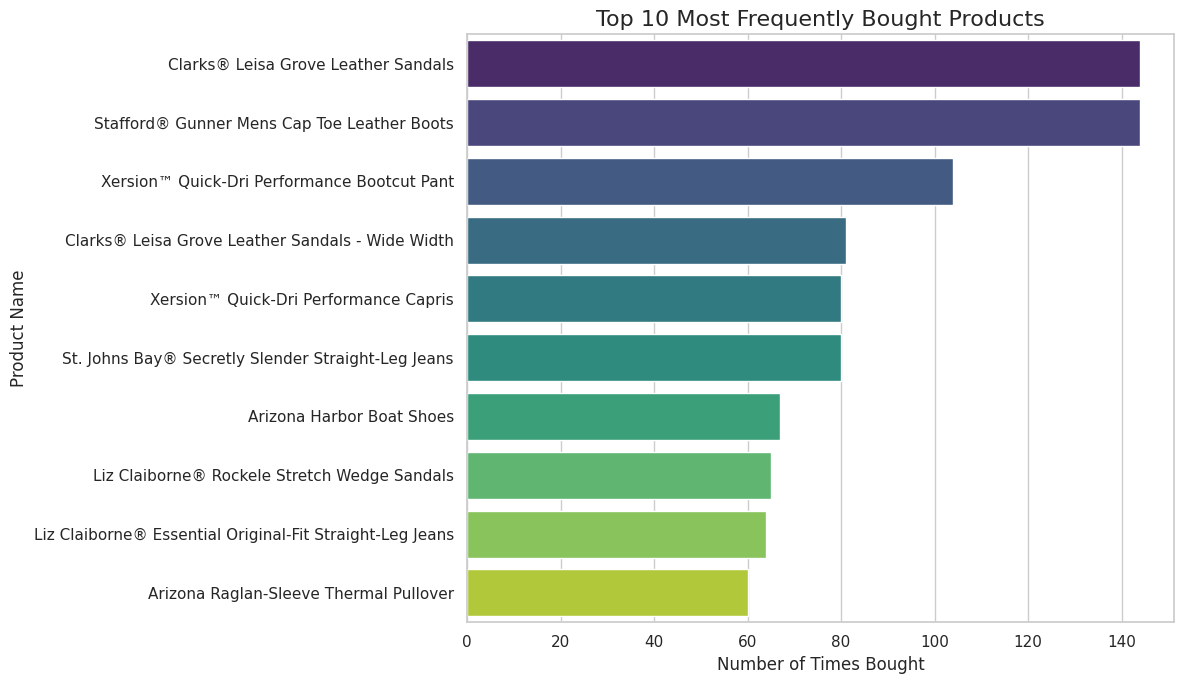

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Get the top 10 products by buy count
top_10_products = product_buy_counts.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_products.values, y=top_10_products.index, palette='viridis')
plt.title('Top 10 Most Frequently Bought Products', fontsize=16)
plt.xlabel('Number of Times Bought', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
product_avg_ratings = products_df.groupby('Name')['Av_Score'].mean().reset_index()
product_avg_ratings = product_avg_ratings.sort_values(by='Av_Score', ascending=False)

print("Average Rating for Each Product (Top 10 by Rating):")
display(product_avg_ratings.head(10))

print("\nAverage Rating for Each Product (Bottom 10 by Rating):")
display(product_avg_ratings.tail(10))

Average Rating for Each Product (Top 10 by Rating):


,Name,Av_Score
5968,nicole by Nicole Miller® Shorts,5.0
5966,nicole by Nicole Miller® Print Romper - Petite,5.0
2,1 CT. T.W. Certified Diamond 14K White Gold Pr...,5.0
5965,nicole by Nicole Miller® Mixed Metal Multi-Cha...,5.0
5964,nicole by Nicole Miller® Marie Tote,5.0
959,Carters® Peach Drawstring Shorts - Preschool G...,5.0
954,Carters® Floral-Print Sleep & Play - Baby Girl...,5.0
3975,Personalized Sterling Silver Name and Birthsto...,5.0
3961,Perceptions Sleeveless Seamed-Front Shift Dress,5.0
3960,Perceptions Short-Sleeve Paisley A-Line Dress,5.0



Average Rating for Each Product (Bottom 10 by Rating):


,Name,Av_Score
1288,DAmante Long-Sleeve Banded-Collar Shirt - Big ...,1.0
1282,Cuisinart® Velocity Ultra Trio 1-HP Blender/Fo...,1.0
2870,Lisette Storage Ottoman,1.0
2869,Linsay® 10.1 Kids Fun Tab Quadcore 8Gb 1024X60...,1.0
4383,Seiko® Coutura Mens Two-Tone Stainless Steel S...,1.0
5231,Van Heusen® Bold Shaded Tie,1.0
5229,Va Bien Convertible Torsolette,1.0
4408,Seventeen® Marrakesh Comforter Set & Accessories,1.0
4407,Seventeen® Boho Nikko Square Damask Decorative...,1.0
963,Carters® Short-Sleeve Monkey Creeper - Baby Bo...,1.0


In [ ]:
num_unique_products = products_df['Name'].nunique()
print(f"There are {num_unique_products} different products in the dataset.")

There are 6001 different products in the dataset.


/tmp/ipykernel_370/2987914073.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Av_Score', y='Name', data=top_10_avg_rated_products, palette='viridis')


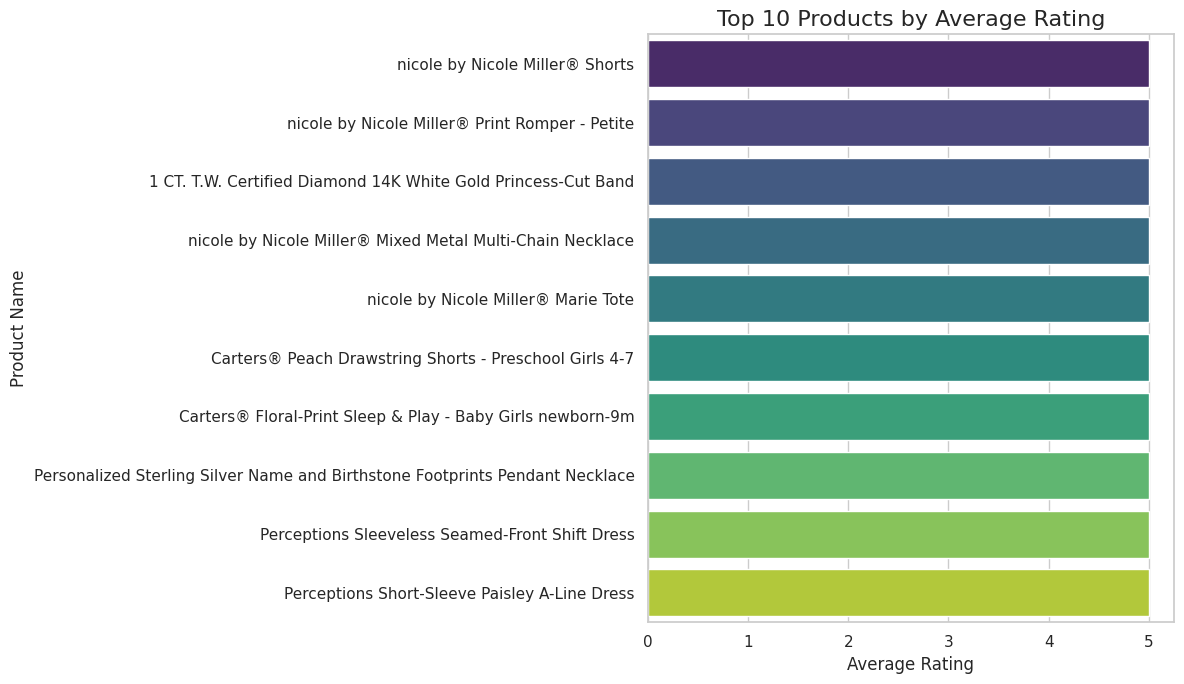

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Sort products by average rating in descending order
product_avg_ratings = products_df.groupby('Name')['Av_Score'].mean().reset_index()
product_avg_ratings_sorted = product_avg_ratings.sort_values(by='Av_Score', ascending=False)

# Get the top 10 products by average rating
top_10_avg_rated_products = product_avg_ratings_sorted.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='Av_Score', y='Name', data=top_10_avg_rated_products, palette='viridis')
plt.title('Top 10 Products by Average Rating', fontsize=16)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()

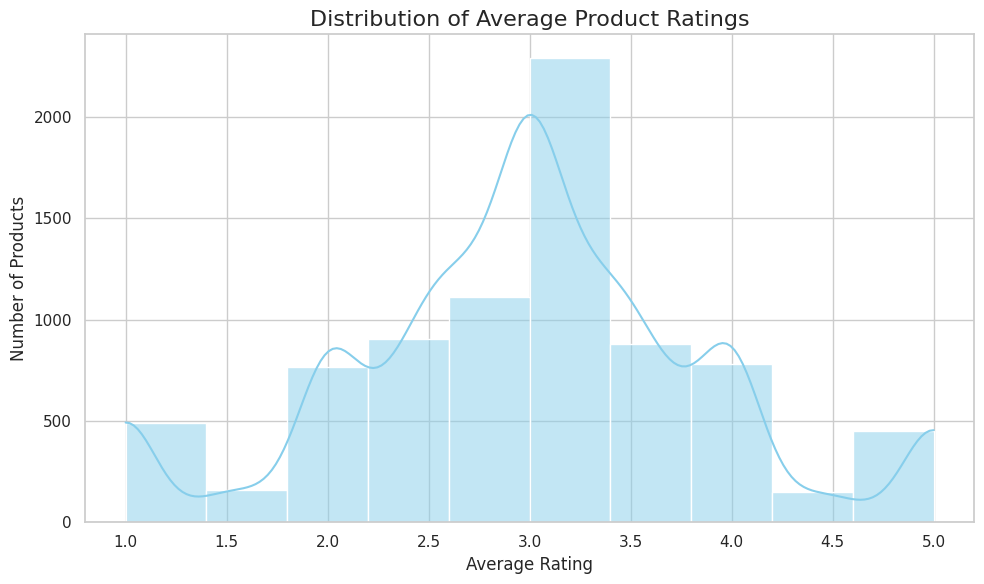

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(products_df['Av_Score'].dropna(), bins=10, kde=True, color='skyblue')
plt.title('Distribution of Average Product Ratings', fontsize=16)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
print("Number of reviews per product (top 10):\n", product_buy_counts.head(10))
print("\nNumber of reviews per product (bottom 10):\n", product_buy_counts.tail(10))

avg_reviews_per_product = product_buy_counts.mean()
print(f"\nAverage number of reviews a product gets: {avg_reviews_per_product:.2f}")

Number of reviews per product (top 10):
 Name
Clarks® Leisa Grove Leather Sandals                         144
Stafford® Gunner Mens Cap Toe Leather Boots                 144
Xersion™ Quick-Dri Performance Bootcut Pant                 104
Clarks® Leisa Grove Leather Sandals - Wide Width             81
Xersion™ Quick-Dri Performance Capris                        80
St. Johns Bay® Secretly Slender Straight-Leg Jeans           80
Arizona Harbor Boat Shoes                                    67
Liz Claiborne® Rockele Stretch Wedge Sandals                 65
Liz Claiborne® Essential Original-Fit Straight-Leg Jeans     64
Arizona Raglan-Sleeve Thermal Pullover                       60
Name: count, dtype: int64

Number of reviews per product (bottom 10):
 Name
Arizona Print Chino Shorts - Boys 8-20, Husky and Slim    1
Silver-Plated Squiggle Ring                               1
Sleep Chic Short-Sleeve Cotton Sleep Tee                  1
Liz Claiborne® Sleeveless Striped Top - Petite            

/tmp/ipykernel_370/989632975.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_reviewed_products.values, y=top_10_reviewed_products.index, palette='magma')


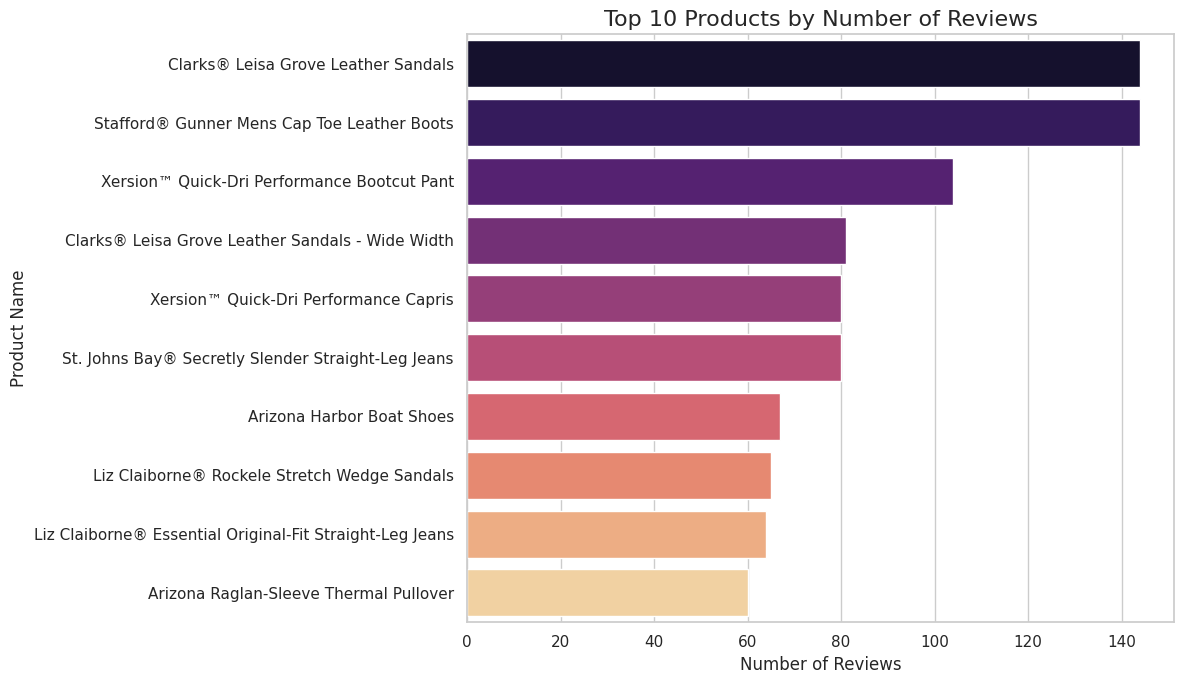

In [ ]:
import matplotlib.pyplot as plt

# Get the top 10 products by review count
top_10_reviewed_products = product_buy_counts.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_reviewed_products.values, y=top_10_reviewed_products.index, palette='magma')
plt.title('Top 10 Products by Number of Reviews', fontsize=16)
plt.xlabel('Number of Reviews', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()